# Setup and Import

In [1241]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.metrics import pairwise_distances

np.random.seed(0)

## 1. Data Familiarization 

In [1242]:
data = fetch_california_housing()

X = pd.DataFrame(data.data, columns=data.feature_names)
Y = pd.Series(data.target, name="HouseValue")
df = pd.concat([X, Y], axis=1)

In [1243]:
Y.head()

0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: HouseValue, dtype: float64

<Axes: >

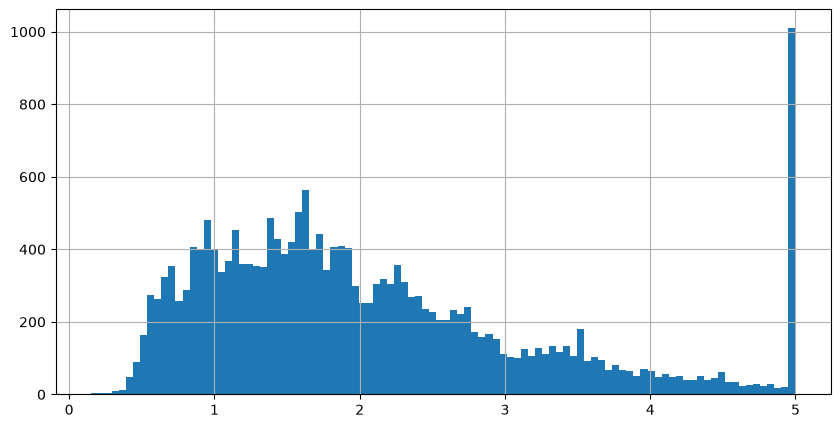

In [1244]:
Y.hist(bins=100, figsize=(10, 5))

In [1245]:
df.head(5)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HouseValue
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [1246]:
df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
HouseValue    0
dtype: int64

In [1247]:
df.duplicated().sum()

np.int64(0)

In [1248]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   HouseValue  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [1249]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HouseValue
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


array([[<Axes: title={'center': 'MedInc'}>,
        <Axes: title={'center': 'HouseAge'}>,
        <Axes: title={'center': 'AveRooms'}>],
       [<Axes: title={'center': 'AveBedrms'}>,
        <Axes: title={'center': 'Population'}>,
        <Axes: title={'center': 'AveOccup'}>],
       [<Axes: title={'center': 'Latitude'}>,
        <Axes: title={'center': 'Longitude'}>,
        <Axes: title={'center': 'HouseValue'}>]], dtype=object)

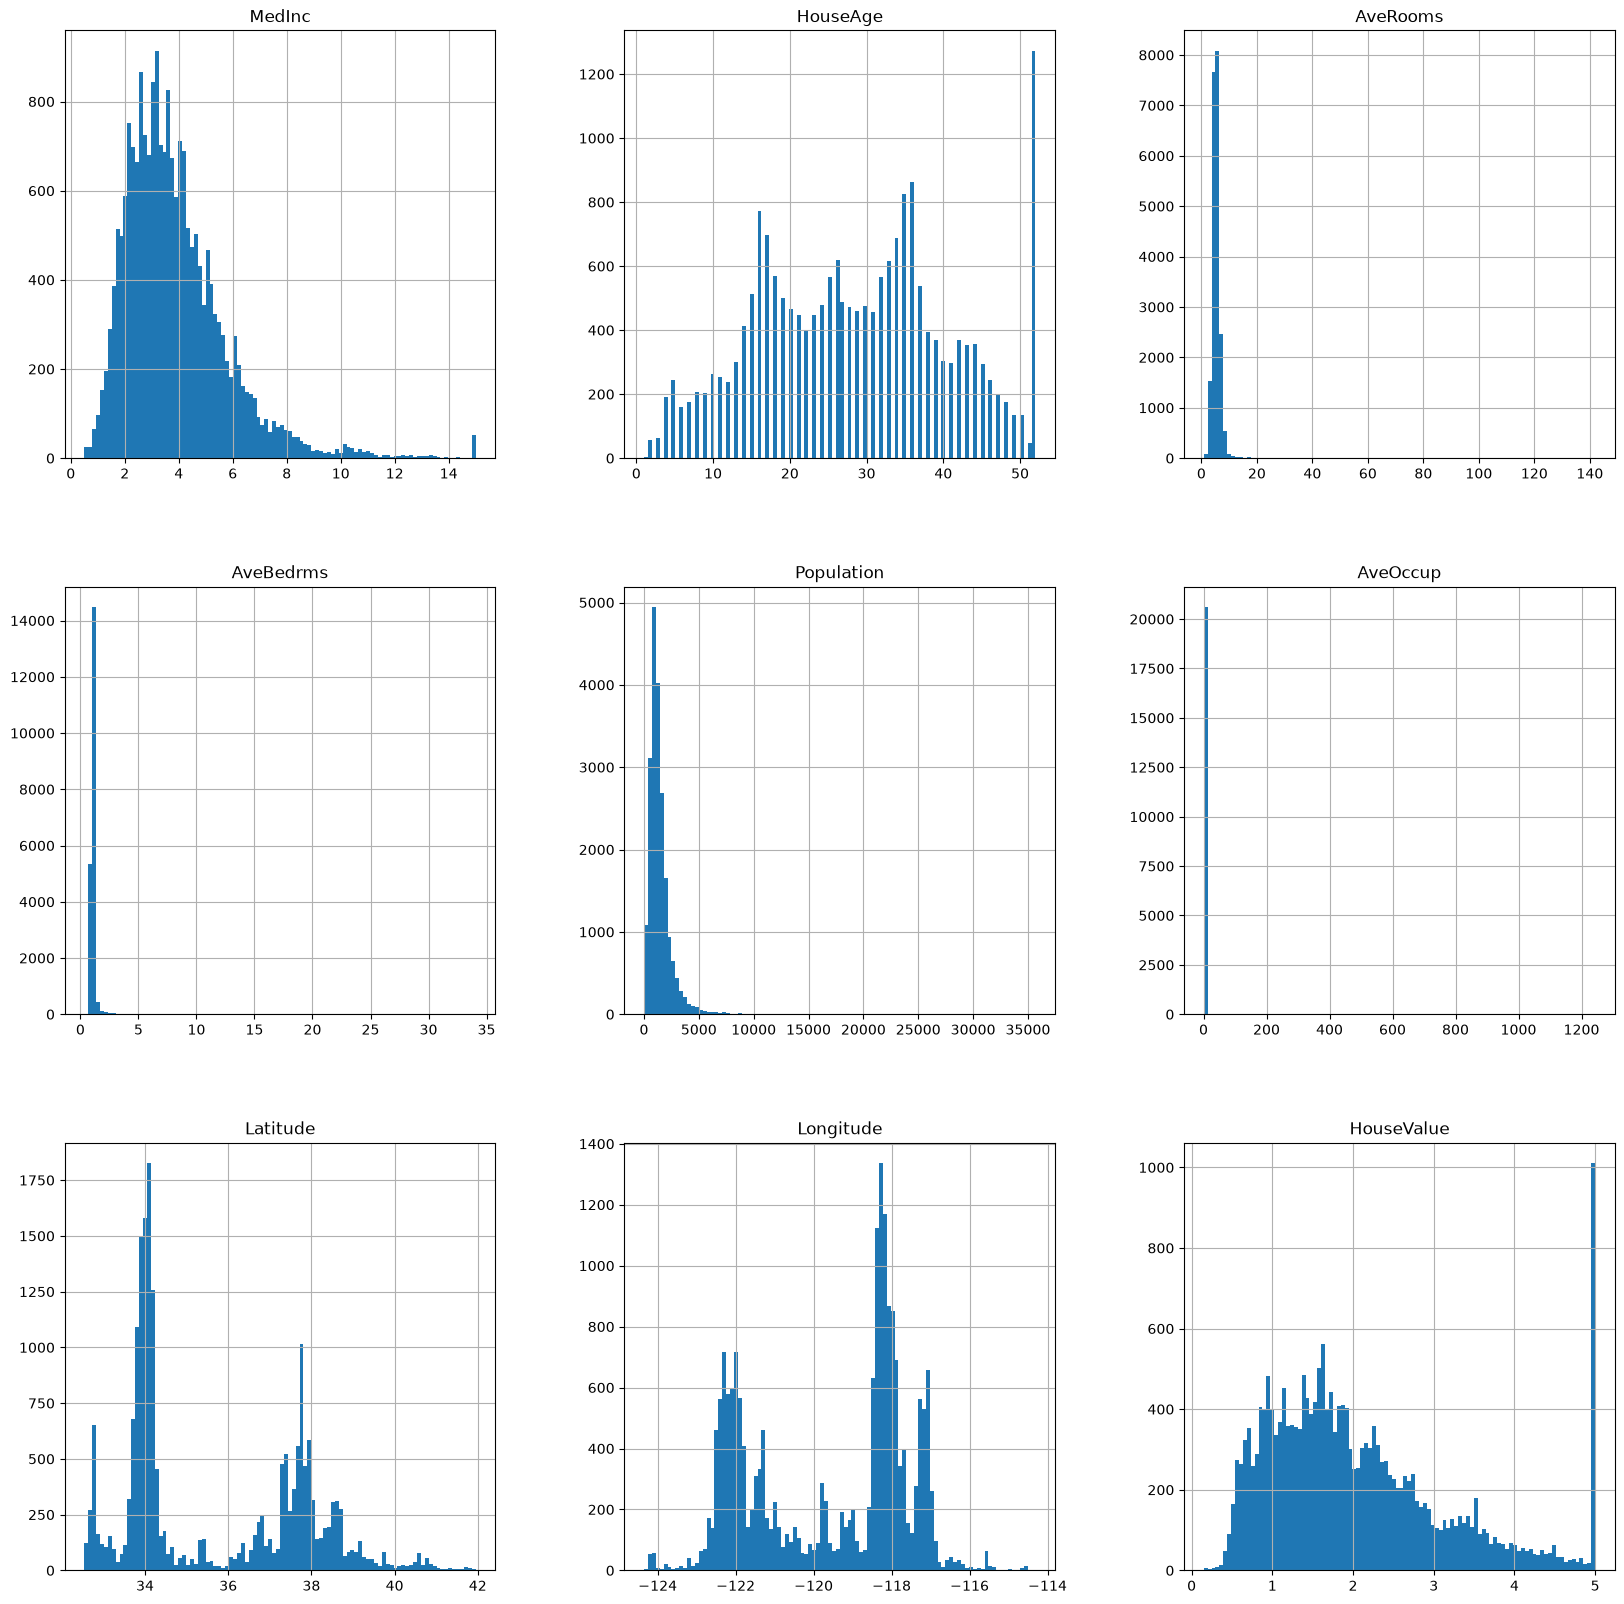

In [1250]:
df.hist(bins= 100, figsize=(20, 20))

<Axes: xlabel='Latitude', ylabel='Longitude'>

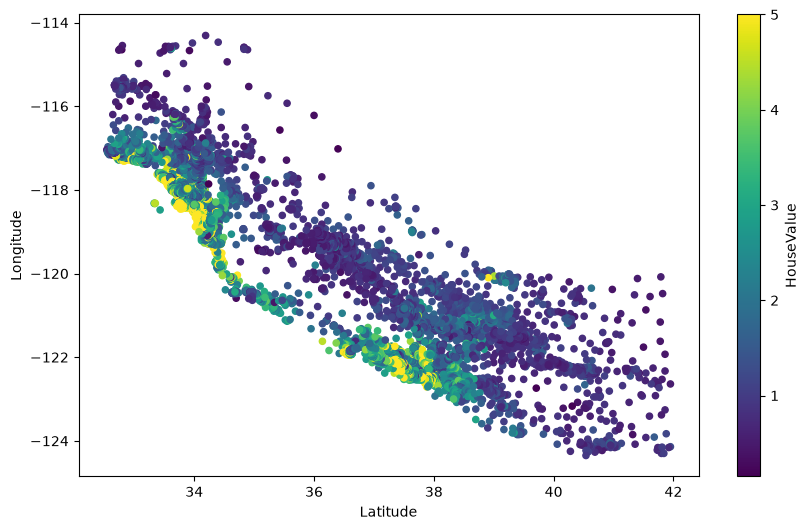

In [1251]:
df.plot(kind='scatter', x='Latitude', y='Longitude', alpha=1, figsize=(10, 6), c='HouseValue', cmap='viridis')

## 2. Two Ways to Draw a Shape Through Data 

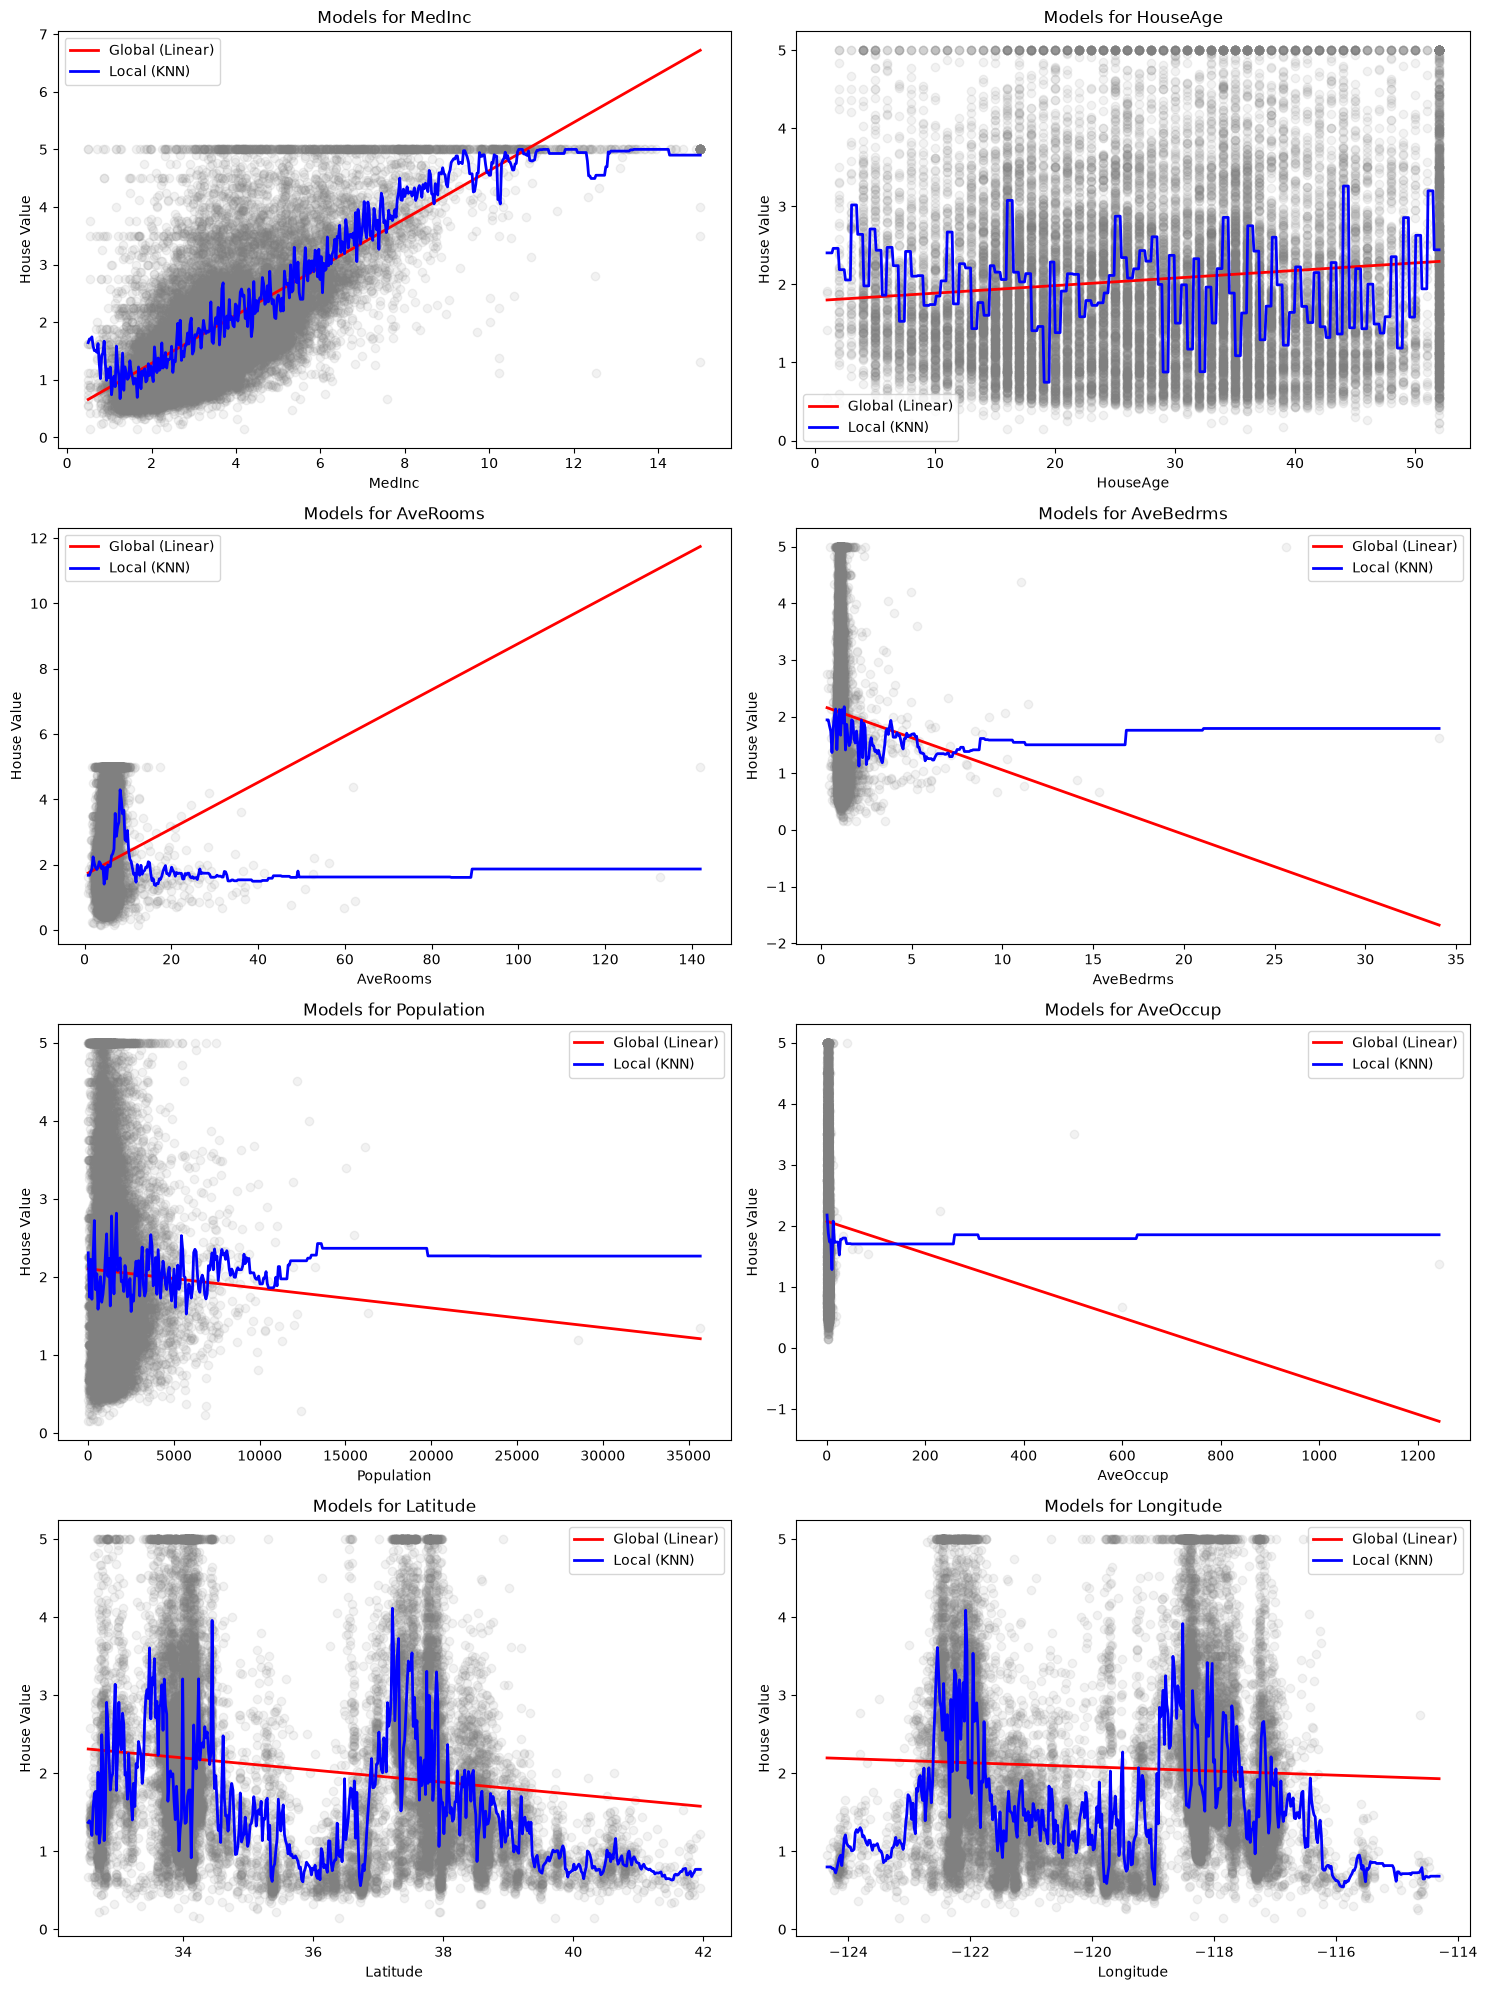

In [1252]:
features = [col for col in df.columns if col != 'HouseValue']
y_target = df['HouseValue'].values

# Set up a grid for the plots (4 rows, 2 columns for 8 features)
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 20))
axes = axes.flatten()

# Loop through each feature to fit models and plot
for idx, feature in enumerate(features):
    X_subset = df[[feature]].values
    
    # Fit Global Model
    linear_model = LinearRegression()
    linear_model.fit(X_subset, y_target)
    
    # Fit Local Model
    knn_model = KNeighborsRegressor(n_neighbors=15)
    knn_model.fit(X_subset, y_target)
    
    # Generate prediction lines
    X_line = np.linspace(X_subset.min(), X_subset.max(), 500).reshape(-1, 1)
    y_linear_pred = linear_model.predict(X_line)
    y_knn_pred = knn_model.predict(X_line)
    
    # Plotting on the current subplot
    ax = axes[idx]
    ax.scatter(X_subset, y_target, color='gray', alpha=0.1)
    ax.plot(X_line, y_linear_pred, color='red', linewidth=2, label='Global (Linear)')
    ax.plot(X_line, y_knn_pred, color='blue', linewidth=2, label='Local (KNN)')
    
    ax.set_xlabel(feature)
    ax.set_ylabel('House Value')
    ax.set_title(f'Models for {feature}')
    ax.legend()

plt.tight_layout()
plt.show()


## 3 What Does It Mean to Be Right?

Mean of MedInc: 3.87
Median of MedInc: 3.53


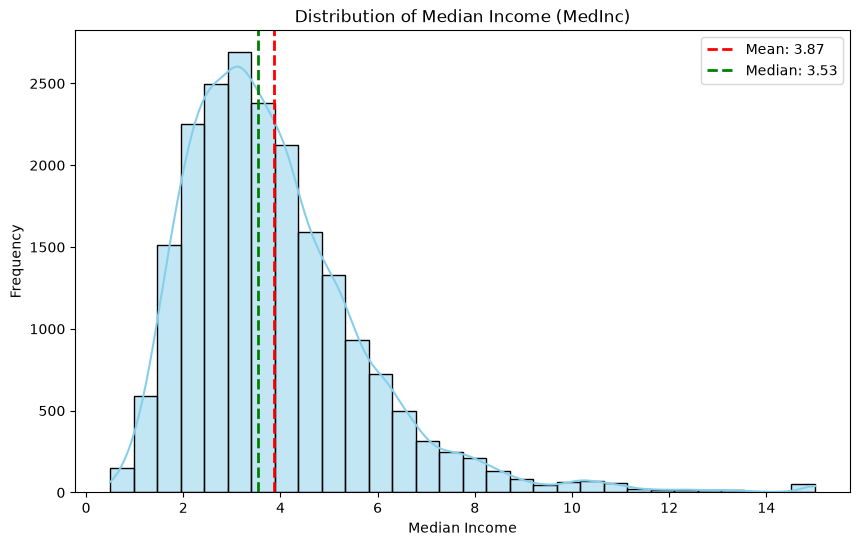

In [1253]:

df_subset = df[['MedInc']]
mean = df_subset.mean()
median = df_subset.median()

print(f"Mean of MedInc: {mean.values[0]:.2f}")
print(f"Median of MedInc: {median.values[0]:.2f}")

# plotting the distribution of MedInc
plt.figure(figsize=(10, 6))
sns.histplot(df_subset['MedInc'], bins=30, kde=True, color='skyblue')
plt.axvline(mean.values[0], color='red', linestyle='dashed', linewidth
=2, label=f'Mean: {mean.values[0]:.2f}')
plt.axvline(median.values[0], color='green', linestyle='dashed', linewidth=2, label=f'Median: {median.values[0]:.2f}')
plt.title('Distribution of Median Income (MedInc)')
plt.xlabel('Median Income')
plt.ylabel('Frequency')
plt.legend()
plt.show()



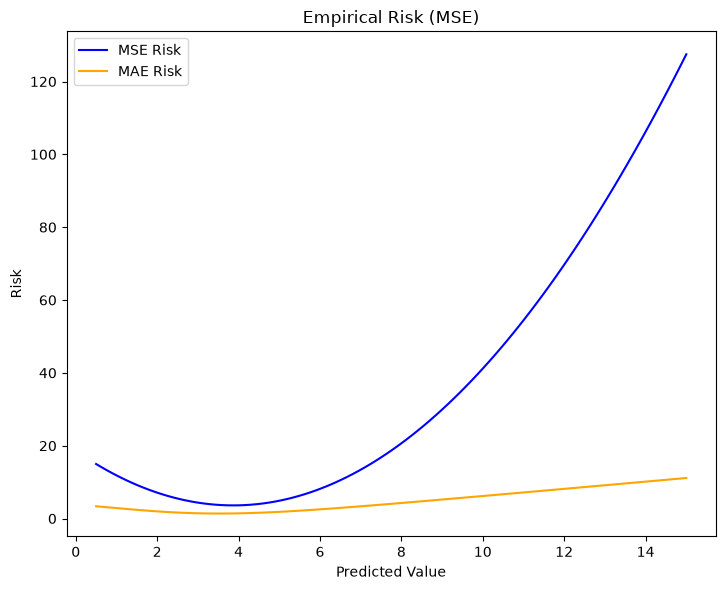

In [ ]:
predictions = np.linspace(df_subset.min(), df_subset.max(), 100)

mse_risk = [np.mean((df_subset - p)**2) for p in predictions]
mae_risk = [np.mean(np.abs(df_subset - p)) for p in predictions]

# plotting the Empirical Risk for MSE and MAE
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(predictions, mse_risk, color='blue', label='MSE Risk')
plt.plot(predictions, mae_risk, color='orange', label='MAE Risk')
plt.title('Empirical Risk (MSE)')
plt.xlabel('Predicted Value')
plt.ylabel('Risk')
plt.legend()
plt.tight_layout()
plt.show()


### 4.When Neighborhoods Stop Being Local 

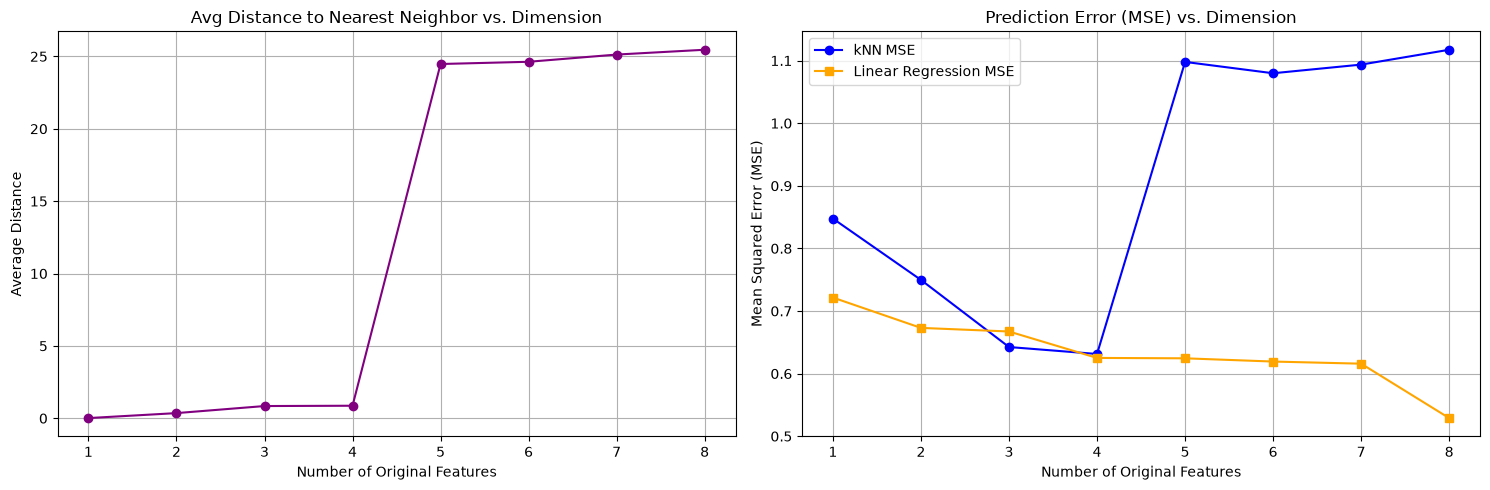

In [1255]:
features = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

dimensions = []
distances = []
knn_errors = []
lr_errors = []

for i in range(len(features)):
    # Incrementally select features: ['MedInc'] -> ['MedInc', 'HouseAge'] -> ...
    current_features = features[:i+1]
    dimensions.append(len(current_features))
    
    # Complete the data slicing
    X_subset = df[current_features]
    Y_target = df['HouseValue']
    
    # Split the data into train and test sets
    x_train, x_test, y_train, y_test = train_test_split(X_subset, Y_target, test_size=0.2, random_state=0)
    
    # 1. Calculate Average Distance to Nearest Neighbor
    sample_x = x_train.sample(n=500, random_state=0)
    dist_matrix = pairwise_distances(sample_x)
    np.fill_diagonal(dist_matrix, np.inf) # Ignore self-distance
    distances.append(dist_matrix.min(axis=1).mean())
    
    # 2. kNN Prediction Error[cite: 1]
    knn = KNeighborsRegressor(n_neighbors=5)
    knn.fit(x_train, y_train)
    knn_errors.append(mean_squared_error(y_test, knn.predict(x_test)))
    
    # 3. Linear Regression Prediction Error[cite: 1]
    lr = LinearRegression()
    lr.fit(x_train, y_train)
    lr_errors.append(mean_squared_error(y_test, lr.predict(x_test)))

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot Distance
ax1.plot(dimensions, distances, marker='o', color='purple')
ax1.set_title('Avg Distance to Nearest Neighbor vs. Dimension')
ax1.set_xlabel('Number of Original Features')
ax1.set_ylabel('Average Distance')
ax1.grid(True)

# Plot Error
ax2.plot(dimensions, knn_errors, marker='o', label='kNN MSE', color='blue')
ax2.plot(dimensions, lr_errors, marker='s', label='Linear Regression MSE', color='orange')
ax2.set_title('Prediction Error (MSE) vs. Dimension')
ax2.set_xlabel('Number of Original Features')
ax2.set_ylabel('Mean Squared Error (MSE)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

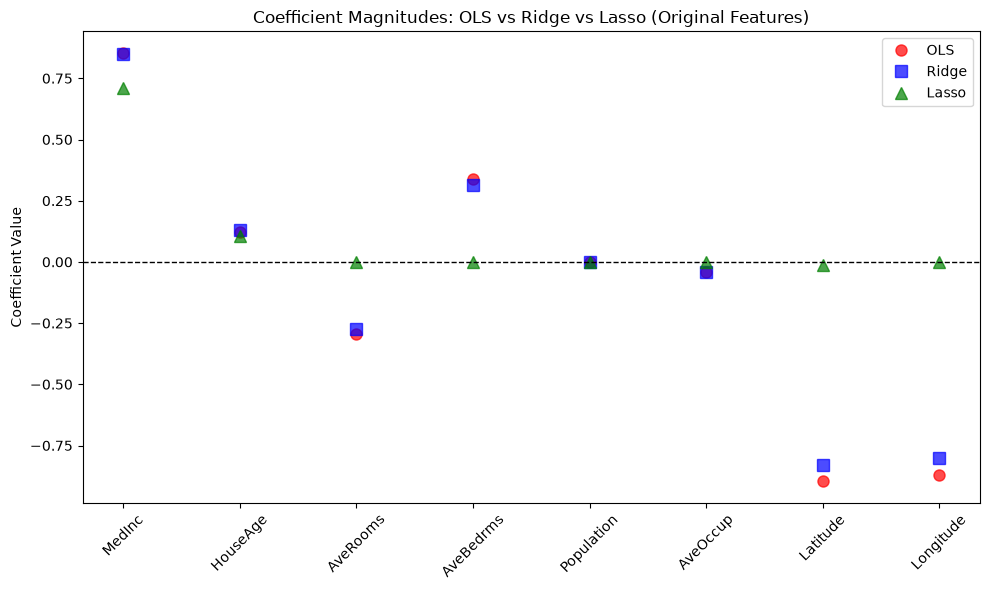

OLS Test MSE: 0.556
Ridge Test MSE: 0.553
Lasso Test MSE: 0.680


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# 1. Setup Data using ONLY the original 8 features
X = df.drop(columns=['HouseValue'])
y = df['HouseValue']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardize features (Crucial for regularized models so penalties are fair)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Fit Models
# Global Model: Ordinary Least Squares (Unrestricted)
ols = LinearRegression()
ols.fit(X_train_scaled, y_train)

# Structured Model 1: Ridge (L2 Penalty)
# Using a high alpha to make the shrinkage visually obvious
ridge = Ridge(alpha=100.0) 
ridge.fit(X_train_scaled, y_train)

# Structured Model 2: Lasso (L1 Penalty)
# Using alpha=0.1 to force sparsity
lasso = Lasso(alpha=0.1) 
lasso.fit(X_train_scaled, y_train)

# 3. Visualization: Coefficient Plot
fig, ax = plt.subplots(figsize=(10, 6))

feature_names = X.columns
x_pos = range(len(feature_names))

ax.plot(x_pos, ols.coef_, alpha=0.7, linestyle='none', marker='o', markersize=8, color='red', label='OLS')
ax.plot(x_pos, ridge.coef_, alpha=0.7, linestyle='none', marker='s', markersize=8, color='blue', label='Ridge')
ax.plot(x_pos, lasso.coef_, alpha=0.7, linestyle='none', marker='^', markersize=8, color='green', label='Lasso')

ax.set_xticks(x_pos)
ax.set_xticklabels(feature_names, rotation=45)
ax.set_title("Coefficient Magnitudes: OLS vs Ridge vs Lasso")
ax.set_ylabel("Coefficient Value")
ax.axhline(0, color='black', linewidth=1, linestyle='--')

ax.legend()
plt.tight_layout()
plt.show()

# Print the Test MSEs for comparison
print(f"OLS Test MSE: {mean_squared_error(y_test, ols.predict(X_test_scaled)):.3f}")
print(f"Ridge Test MSE: {mean_squared_error(y_test, ridge.predict(X_test_scaled)):.3f}")
print(f"Lasso Test MSE: {mean_squared_error(y_test, lasso.predict(X_test_scaled)):.3f}")

### Remove outliers using IQR method

In [1257]:
# remove outliers using IQR method
features = df.columns  # Exclude the target variable
for feature in features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[feature] >= lower_bound) & (df[feature] <= upper_bound)]

array([[<Axes: title={'center': 'MedInc'}>,
        <Axes: title={'center': 'HouseAge'}>,
        <Axes: title={'center': 'AveRooms'}>],
       [<Axes: title={'center': 'AveBedrms'}>,
        <Axes: title={'center': 'Population'}>,
        <Axes: title={'center': 'AveOccup'}>],
       [<Axes: title={'center': 'Latitude'}>,
        <Axes: title={'center': 'Longitude'}>,
        <Axes: title={'center': 'HouseValue'}>]], dtype=object)

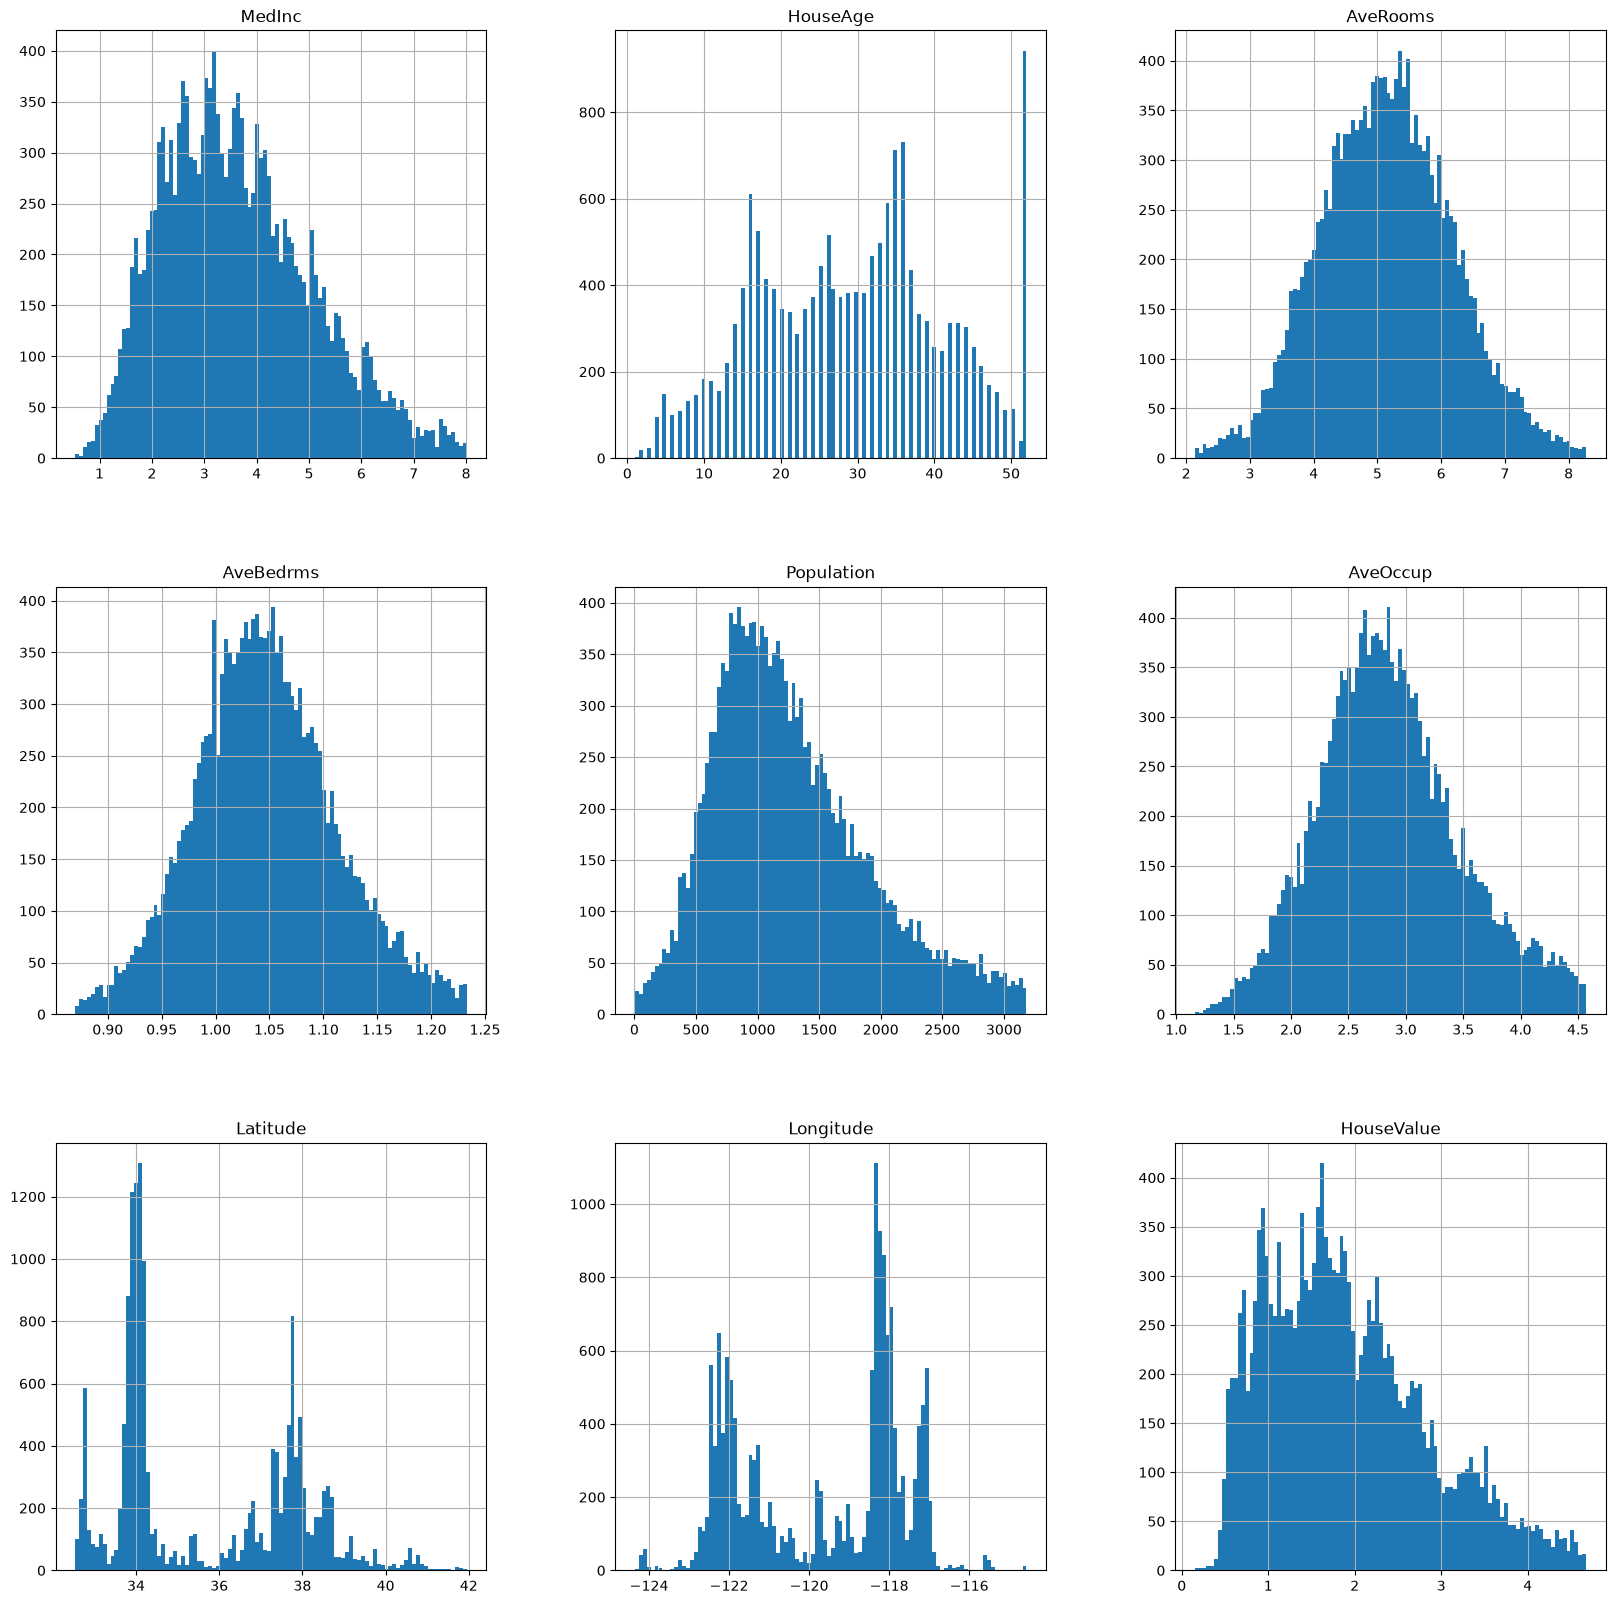

In [1258]:
df.hist(bins= 100, figsize=(20, 20))

In [1259]:
df.info()

<class 'pandas.DataFrame'>
Index: 16232 entries, 3 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      16232 non-null  float64
 1   HouseAge    16232 non-null  float64
 2   AveRooms    16232 non-null  float64
 3   AveBedrms   16232 non-null  float64
 4   Population  16232 non-null  float64
 5   AveOccup    16232 non-null  float64
 6   Latitude    16232 non-null  float64
 7   Longitude   16232 non-null  float64
 8   HouseValue  16232 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB


### Drop unwanted columns

<Axes: >

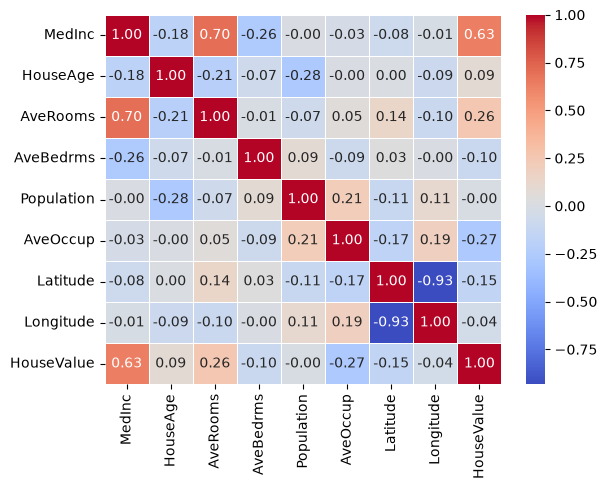

In [1260]:
heatmap = df.corr()
sns.heatmap(heatmap, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

In [1261]:
df = df.drop(columns=['Population'])

## Train Test Split and Standardization

In [1262]:
x = df.drop(columns=["HouseValue"])
y = df["HouseValue"]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

In [1263]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


In [1264]:
x_train_scaled

array([[ 1.06369454,  0.38162486,  0.18321437, ..., -0.38654679,
         0.40591062, -0.9847837 ],
       [-1.15406976, -0.93119397, -0.85719488, ...,  0.78710743,
        -0.838271  ,  0.73826484],
       [ 0.57959106, -0.27478456, -0.1535143 , ..., -0.67554405,
        -0.838271  ,  0.63277207],
       ...,
       [ 0.97355114,  0.46367603,  1.44505668, ..., -0.09657279,
         1.36584102, -0.869244  ],
       [ 0.06836109, -1.34144986,  1.10351619, ...,  0.24685655,
        -0.59129862,  1.15521244],
       [-0.24060265, -1.01324515,  0.60509822, ..., -0.36554321,
         2.25121371, -0.69844619]], shape=(12985, 7))

# Model Training

#### Importing 

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import AdaBoostRegressor

### Training multiple Model

In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics.pairwise import pairwise_distances
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
import numpy as np

# Define the models to evaluate
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(),
    'k-Nearest Neighbors': KNeighborsRegressor(),
    'Random Forest': RandomForestRegressor(),
    'Gradient Boost': GradientBoostingRegressor(),
    'Adaboost': AdaBoostRegressor(),
    'Xgboost': XGBRegressor(),
    'LightGBM': LGBMRegressor(),
    'CatBoost': CatBoostRegressor(verbose=0)
}

# Train and evaluate each model
for model_name, model in models.items():
    # Assuming x_train_scaled and x_test_scaled based on your traceback
    model.fit(x_train_scaled, y_train)

    y_train_pred = model.predict(x_train_scaled)
    y_test_pred = model.predict(x_test_scaled)
    

    # Train set performance
    train_mse = mean_squared_error(y_train, y_train_pred)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_r2 = r2_score(y_train, y_train_pred)
 

    # Test set performance
    test_mse = mean_squared_error(y_test, y_test_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    # Print the performance metrics for each model
    print(model_name)

    print('Model performance for Train set')
    print("Mean Squared Error: {:.4f}".format(train_mse))
    print("Mean Absolute Error: {:.4f}".format(train_mae))
    print("R^2 Score: {:.4f}".format(train_r2))
    print("-" * 35)

    print('Model performance for Test set')
    print("Mean Squared Error: {:.4f}".format(test_mse))
    print("Mean Absolute Error: {:.4f}".format(test_mae))
    print("R^2 Score: {:.4f}".format(test_r2))
    print("=" * 35)
    print("\n")

Linear Regression
Model performance for Train set
Mean Squared Error: 0.3168
Mean Absolute Error: 0.4266
R^2 Score: 0.6303
-----------------------------------
Model performance for Test set
Mean Squared Error: 0.3068
Mean Absolute Error: 0.4194
R^2 Score: 0.6582


Decision Tree
Model performance for Train set
Mean Squared Error: 0.0000
Mean Absolute Error: 0.0000
R^2 Score: 1.0000
-----------------------------------
Model performance for Test set
Mean Squared Error: 0.3665
Mean Absolute Error: 0.4071
R^2 Score: 0.5917


k-Nearest Neighbors
Model performance for Train set
Mean Squared Error: 0.1964
Mean Absolute Error: 0.3183
R^2 Score: 0.7708
-----------------------------------
Model performance for Test set
Mean Squared Error: 0.2893
Mean Absolute Error: 0.3858
R^2 Score: 0.6777


Random Forest
Model performance for Train set
Mean Squared Error: 0.0257
Mean Absolute Error: 0.1082
R^2 Score: 0.9700
-----------------------------------
Model performance for Test set
Mean Squared Error: 0